In [3]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian import *
from scripts.self_consistency import *

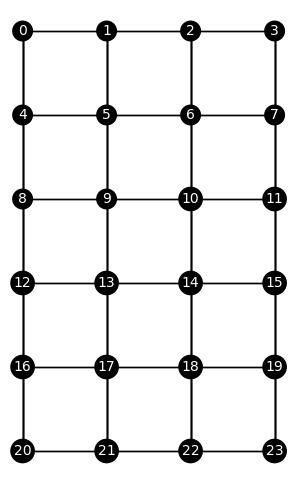

In [4]:
Y,X = 6,4

lattice = Lattice(X, Y, pbc_x=False, pbc_y=True)
lattice.plot()

In [5]:
t = 1
mu = 1.8* t
Y,X = 36,36

lattice = Lattice(X, Y, pbc_x=False, pbc_y=True)

V0 = 2 * t
x, y = cp.meshgrid(cp.arange(X), cp.arange(Y), indexing="ij")
idxs = cp.flatnonzero((x >= (X//2)).T.ravel())  # transpose swaps flatten order
V = cp.zeros(lattice.num_sites)
V[idxs] = V0

U0 = 2 * t
x, y = cp.meshgrid(cp.arange(X), cp.arange(Y), indexing="ij")
idxs = cp.flatnonzero((x >= (X//2)).T.ravel())  # transpose swaps flatten order
U = cp.ones(lattice.num_sites) * U0
U[idxs] = 0

gap_p= cp.array([0.1, 0.1j]) * t

H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)

for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    H.set_block(i,i, block)

for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0

    gap_ij = unconventional_gap(lattice.get_disp(i,j), gap_p=gap_p)
    block[0:2, 2:4] = gap_ij
    gap_ji = unconventional_gap(lattice.get_disp(j,i), gap_p=gap_p)
    block[2:4, 0:2] = gap_ji.conj().T

    H.set_block(i,j, block)



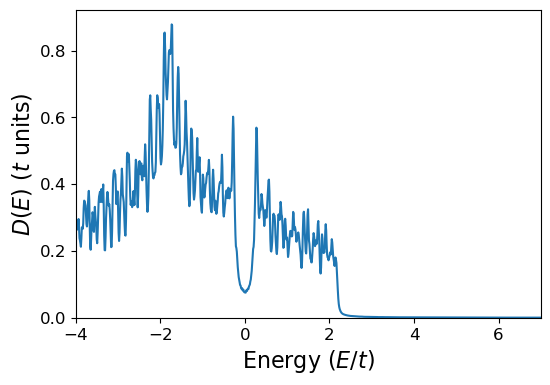

In [6]:
energies = cp.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.02, drop_matrix=False)
plt.figure(figsize=(6,4))
plt.plot(cp.asnumpy(energies), cp.asnumpy(dos_values))
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

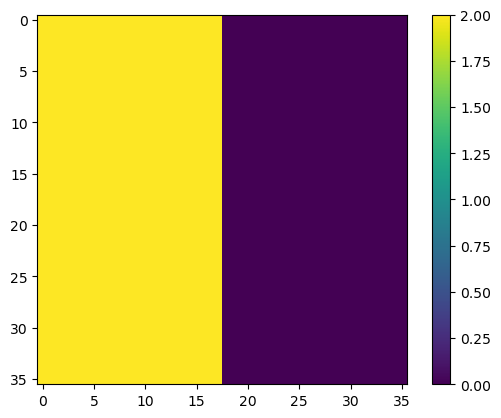

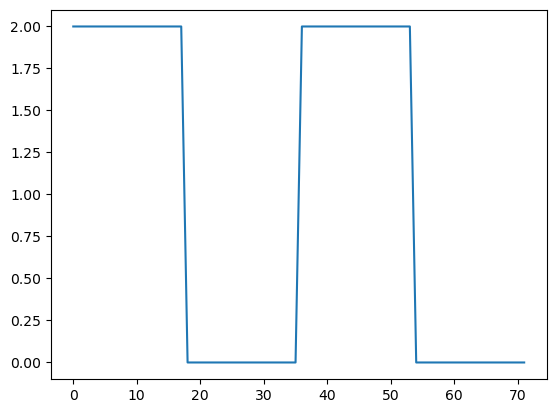

In [7]:
plt.figure()
plt.imshow(cp.asnumpy(U.reshape(X,Y)))
plt.colorbar()

plt.figure()
plt.plot(cp.asnumpy(U)[:72])

In [ ]:
F0, F, Fuu, Fdd = bdg_self_consistency(H,U=U,V=V,T=0,atol=1e-3,rtol=1e-1, max_iter=200, with_corr=True, verbose=True)

Iteration 1:                
Abs: 3.3603080335722413                
Rel: 71.4982517268779                
Index: 652355                
Correlation:                 0j                
Corr_new:                 (7.28583859910259e-17+0.056908836341431526j)                
Correlation_dd:                     0j                
Corr_dd_new:                     (1.63484135083658e-16+4.620463083318538e-16j)                
Correlation_uu:                     0j                
Corr_uu_new:                     (3.13774884980883e-16+3.859759734048396e-17j)
F0 bool: True
F bool: False
Fuu bool: True
Fdd bool: True
Iteration 2:                
Abs: 2.1558096205340123                
Rel: 1379.5542184580765                
Index: 1073880                
Correlation:                 (1.0408340855860843e-16+0.05690883634143147j)                
Corr_new:                 (1.0972125985553305e-16+0.0054348321987949194j)                
Correlation_dd:                     (1.63484135083658e-16+4.62046

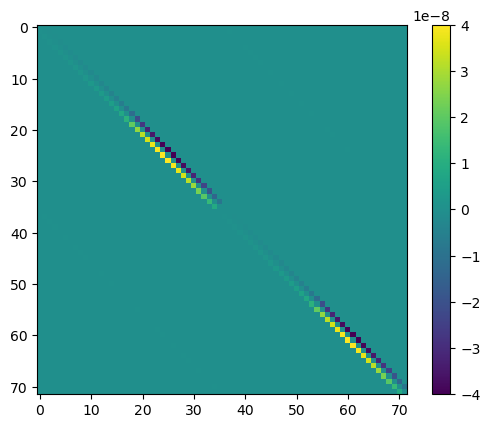

In [7]:
plt.figure()
plt.imshow(cp.asnumpy(cp.real(F))[0:72,0:72])
colorbar = plt.colorbar()

In [8]:
F0, F, Fuu, Fdd = H.get_correlations()
# free_energy = H.free_energy(U=0, V=V0, V_prime=V0, temperature=0, drop_matrix=False)
# print(f"Free energy: {free_energy}")
F_S = cp.zeros((H.lattice.num_sites, H.lattice.num_sites), dtype=cp.complex128)
F_T = cp.zeros((H.lattice.num_sites, H.lattice.num_sites), dtype=cp.complex128)

F_xplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_xminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_yplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_yminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)

for i,j in H.lattice.edges:
        F_S[i][j] = (F[i][j]+F[j][i])/2
        F_T[i][j] = (F[i][j]-F[j][i])/2
        dir = H.lattice.get_dir(i,j)
        if dir == "+x":
            F_xplus[i] += F[i][j]
        elif dir == "-x":
            F_xminus[i] += F[i][j]
        elif dir == "+y":
            F_yplus[i] += F[i][j]
        elif dir == "-y":
            F_yminus[i] += F[i][j]
    


-1.5637786557703965e-08
-0.027685848370862833
1.1321445804268705e-18
8.729667138190629e-19


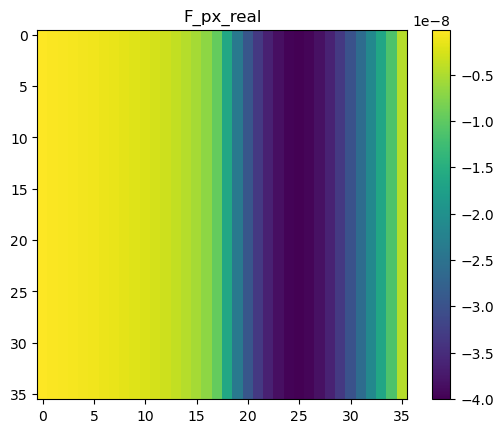

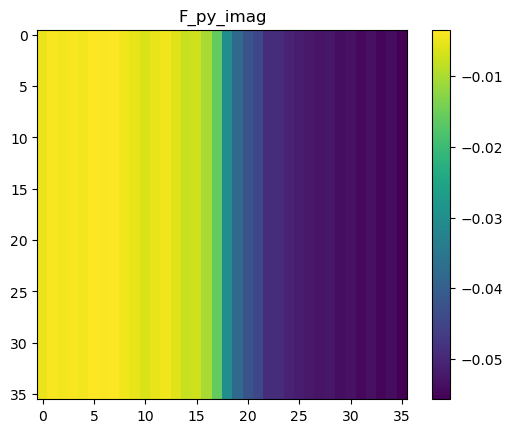

In [9]:
plt.figure()
plt.imshow((np.real(cp.asnumpy((F_xplus-F_xminus)/2).reshape(36,36))), label="F_T_real")
plt.title("F_px_real")
plt.colorbar()
print(np.average((np.real(cp.asnumpy((F_xplus-F_xminus)/2)))))
plt.figure()
plt.imshow((np.imag(cp.asnumpy((F_yplus-F_yminus)/2).reshape(36,36))), label="F_T_imag")
print(np.average((np.imag(cp.asnumpy((F_yplus-F_yminus)/2)))))
print(np.average((np.real(cp.asnumpy((F_xplus+F_xminus-F_yplus-F_yminus)/4)))))
print(np.average((np.real(cp.asnumpy((F_xplus+F_xminus+F_yplus+F_yminus)/4)))))

plt.title("F_py_imag")
plt.colorbar()

plt.show()

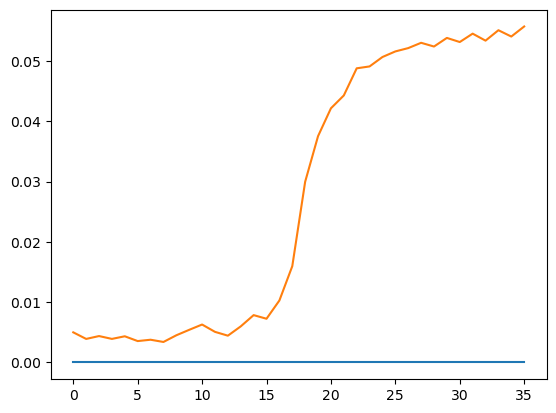

In [ ]:
plt.plot(-(np.real(cp.asnumpy((F_xplus-F_xminus)/2)[0:36])))
# plt.plot(-(np.imag(cp.asnumpy((F_yplus-F_yminus)/2)[0:36])))
